### RFM 분석 실습
- Recency: 얼마나 최근에 구매했는가
- Frequency: 얼마나 자주 구매했는가
- Monetary: 얼마나 많은 금액을 지출했는가

### 고객 분석
`customer_order_data.csv`
- CustomerID: 고객 번호
- PurchaseDate: 구매 날짜
- TransactionAmount: 결제 금액 
- ProductInformation: 상품 정보
- OrderID: 주문 번호
- Location: 주문 지역

In [41]:
import pandas as pd

co_df = pd.read_csv('./datasets/customer_order_data.csv')
co_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          1000 non-null   int64  
 1   PurchaseDate        1000 non-null   str    
 2   TransactionAmount   1000 non-null   float64
 3   ProductInformation  1000 non-null   str    
 4   OrderID             1000 non-null   int64  
 5   Location            1000 non-null   str    
dtypes: float64(1), int64(2), str(3)
memory usage: 47.0 KB


In [42]:
co_df

,CustomerID,PurchaseDate,TransactionAmount,ProductInformation,OrderID,Location
0,8814,2023-04-11,943.31,Product C,890075,Tokyo
1,2188,2023-04-11,463.70,Product A,176819,London
2,4608,2023-04-11,80.28,Product A,340062,New York
3,2559,2023-04-11,221.29,Product A,239145,London
4,9482,2023-04-11,739.56,Product A,194545,Paris
...,...,...,...,...,...,...
995,2970,2023-06-10,759.62,Product B,275284,London
996,6669,2023-06-10,941.50,Product C,987025,New York
997,8836,2023-06-10,545.36,Product C,512842,London
998,1440,2023-06-10,729.94,Product B,559753,Paris


In [43]:
co_df.columns = ['ID', 'Date', 'Amount', 'Information', 'OrderID', 'City']
co_df

,ID,Date,Amount,Information,OrderID,City
0,8814,2023-04-11,943.31,Product C,890075,Tokyo
1,2188,2023-04-11,463.70,Product A,176819,London
2,4608,2023-04-11,80.28,Product A,340062,New York
3,2559,2023-04-11,221.29,Product A,239145,London
4,9482,2023-04-11,739.56,Product A,194545,Paris
...,...,...,...,...,...,...
995,2970,2023-06-10,759.62,Product B,275284,London
996,6669,2023-06-10,941.50,Product C,987025,New York
997,8836,2023-06-10,545.36,Product C,512842,London
998,1440,2023-06-10,729.94,Product B,559753,Paris


In [44]:
co_df.sort_values(by='Date', ascending=False)

,ID,Date,Amount,Information,OrderID,City
999,4759,2023-06-10,804.28,Product D,467544,New York
990,6570,2023-06-10,125.84,Product C,664032,Paris
981,6761,2023-06-10,571.97,Product B,690462,London
982,3213,2023-06-10,700.65,Product B,719531,Tokyo
983,2625,2023-06-10,765.11,Product B,377501,New York
...,...,...,...,...,...,...
1,2188,2023-04-11,463.70,Product A,176819,London
5,8483,2023-04-11,375.23,Product C,691194,Paris
6,8317,2023-04-11,272.56,Product B,826847,New York
7,6911,2023-04-11,433.33,Product C,963918,Tokyo


In [45]:
target = pd.to_datetime('2023-06-10')
co_df['Recency'] = (target - pd.to_datetime(co_df.Date)).dt.days
co_df

,ID,Date,Amount,Information,OrderID,City,Recency
0,8814,2023-04-11,943.31,Product C,890075,Tokyo,60
1,2188,2023-04-11,463.70,Product A,176819,London,60
2,4608,2023-04-11,80.28,Product A,340062,New York,60
3,2559,2023-04-11,221.29,Product A,239145,London,60
4,9482,2023-04-11,739.56,Product A,194545,Paris,60
...,...,...,...,...,...,...,...
995,2970,2023-06-10,759.62,Product B,275284,London,0
996,6669,2023-06-10,941.50,Product C,987025,New York,0
997,8836,2023-06-10,545.36,Product C,512842,London,0
998,1440,2023-06-10,729.94,Product B,559753,Paris,0


In [46]:
co_df.ID.value_counts()

ID
5557    3
4804    3
7363    3
8317    2
9871    2
       ..
2970    1
6669    1
8836    1
1440    1
4759    1
Name: count, Length: 946, dtype: int64

In [47]:
co_df[co_df.ID == 7363]

,ID,Date,Amount,Information,OrderID,City,Recency
249,7363,2023-04-26,262.45,Product C,778120,New York,45
291,7363,2023-04-28,188.02,Product C,726121,London,43
385,7363,2023-05-03,935.85,Product B,284654,London,38


In [48]:
# Recency
rfm_r = co_df.groupby('ID')['Recency'].min().reset_index()
rfm_r.columns = ['ID', 'Recency']

# Frequency
rfm_f = co_df.ID.value_counts().reset_index()
rfm_f.columns = ['ID', 'Frequency']

# Monetary
rfm_m = co_df.groupby('ID')['Amount'].sum().reset_index()
rfm_m.columns = ['ID', 'Monetary']

rfm = pd.merge(rfm_r, rfm_f, on='ID')
rfm = rfm.merge(rfm_m, on='ID')

rfm

,ID,Recency,Frequency,Monetary
0,1011,33,2,1129.02
1,1025,21,1,359.29
2,1029,0,1,704.99
3,1046,43,1,859.82
4,1049,13,1,225.72
...,...,...,...,...
941,9941,42,1,960.53
942,9950,38,1,679.11
943,9954,12,1,798.01
944,9985,57,1,36.10


In [49]:
def scaling_frequency(x):
    return 0 if x == 1 else 1

In [50]:
rfm.Frequency = rfm.Frequency.apply(scaling_frequency)
rfm

,ID,Recency,Frequency,Monetary
0,1011,33,1,1129.02
1,1025,21,0,359.29
2,1029,0,0,704.99
3,1046,43,0,859.82
4,1049,13,0,225.72
...,...,...,...,...
941,9941,42,0,960.53
942,9950,38,0,679.11
943,9954,12,0,798.01
944,9985,57,0,36.10


In [51]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

rfm[['Recency', 'Monetary']] = scaler.fit_transform(rfm[['Recency', 'Monetary']])

In [52]:
rfm.Recency = 1 - rfm.Recency
rfm

,ID,Recency,Frequency,Monetary
0,1011,0.450000,1,0.471795
1,1025,0.650000,0,0.146647
2,1029,1.000000,0,0.292677
3,1046,0.283333,0,0.358080
4,1049,0.783333,0,0.090224
...,...,...,...,...
941,9941,0.300000,0,0.400622
942,9950,0.366667,0,0.281745
943,9954,0.800000,0,0.331970
944,9985,0.050000,0,0.010125


In [53]:
rfm['TotalScore'] = rfm.Recency * 0.4 + rfm.Frequency * 0.1 + rfm.Monetary * 0.5
rfm

,ID,Recency,Frequency,Monetary,TotalScore
0,1011,0.450000,1,0.471795,0.515898
1,1025,0.650000,0,0.146647,0.333323
2,1029,1.000000,0,0.292677,0.546338
3,1046,0.283333,0,0.358080,0.292373
4,1049,0.783333,0,0.090224,0.358446
...,...,...,...,...,...
941,9941,0.300000,0,0.400622,0.320311
942,9950,0.366667,0,0.281745,0.287539
943,9954,0.800000,0,0.331970,0.485985
944,9985,0.050000,0,0.010125,0.025063


In [54]:
co_df.drop(labels='Recency', axis=1, inplace=True)

In [55]:
co_rfm_df = co_df.merge(rfm, on="ID")
co_rfm_df

,ID,Date,Amount,Information,OrderID,City,Recency,Frequency,Monetary,TotalScore
0,8814,2023-04-11,943.31,Product C,890075,Tokyo,0.0,0,0.393348,0.196674
1,2188,2023-04-11,463.70,Product A,176819,London,0.0,0,0.190752,0.095376
2,4608,2023-04-11,80.28,Product A,340062,New York,0.0,0,0.028788,0.014394
3,2559,2023-04-11,221.29,Product A,239145,London,0.0,0,0.088353,0.044177
4,9482,2023-04-11,739.56,Product A,194545,Paris,0.0,0,0.307280,0.153640
...,...,...,...,...,...,...,...,...,...,...
995,2970,2023-06-10,759.62,Product B,275284,London,1.0,0,0.315754,0.557877
996,6669,2023-06-10,941.50,Product C,987025,New York,1.0,0,0.392583,0.596292
997,8836,2023-06-10,545.36,Product C,512842,London,1.0,0,0.225246,0.512623
998,1440,2023-06-10,729.94,Product B,559753,Paris,1.0,0,0.303216,0.551608


In [56]:
import numpy as np

l1, l2 = np.percentile(co_rfm_df.TotalScore, [40, 80])
print(l1, l2)

0.28380638584278145 0.4597864026268805


In [57]:
def get_level(x):
    if x <= l1:
        return 3
    if x <= l2:
        return 2
    return 1

In [58]:
co_rfm_df['Grade'] = co_rfm_df['TotalScore'].apply(get_level)

In [59]:
co_rfm_df.Grade = co_rfm_df.Grade.replace([1, 2, 3], ['Gold', 'Silver', 'Bronze'])
co_rfm_df

,ID,Date,Amount,Information,OrderID,City,Recency,Frequency,Monetary,TotalScore,Grade
0,8814,2023-04-11,943.31,Product C,890075,Tokyo,0.0,0,0.393348,0.196674,Bronze
1,2188,2023-04-11,463.70,Product A,176819,London,0.0,0,0.190752,0.095376,Bronze
2,4608,2023-04-11,80.28,Product A,340062,New York,0.0,0,0.028788,0.014394,Bronze
3,2559,2023-04-11,221.29,Product A,239145,London,0.0,0,0.088353,0.044177,Bronze
4,9482,2023-04-11,739.56,Product A,194545,Paris,0.0,0,0.307280,0.153640,Bronze
...,...,...,...,...,...,...,...,...,...,...,...
995,2970,2023-06-10,759.62,Product B,275284,London,1.0,0,0.315754,0.557877,Gold
996,6669,2023-06-10,941.50,Product C,987025,New York,1.0,0,0.392583,0.596292,Gold
997,8836,2023-06-10,545.36,Product C,512842,London,1.0,0,0.225246,0.512623,Gold
998,1440,2023-06-10,729.94,Product B,559753,Paris,1.0,0,0.303216,0.551608,Gold


In [62]:
co_rfm_df[co_rfm_df.Frequency > 0]['Grade'].value_counts()

Grade
Gold      85
Silver    18
Bronze     2
Name: count, dtype: int64

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ['Bronze', 'Silver', 'Gold']

co_rfm_df['Grade'].value_counts()

Grade
Bronze    400
Silver    400
Gold      200
Name: count, dtype: int64

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10712\2527265413.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Grade', data=co_rfm_df, palette='muted', order=order)


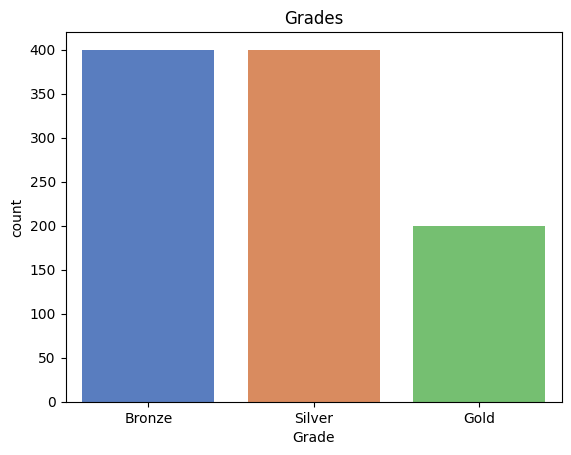

In [64]:
sns.countplot(x='Grade', data=co_rfm_df, palette='muted', order=order)
plt.title('Grades')
plt.show()

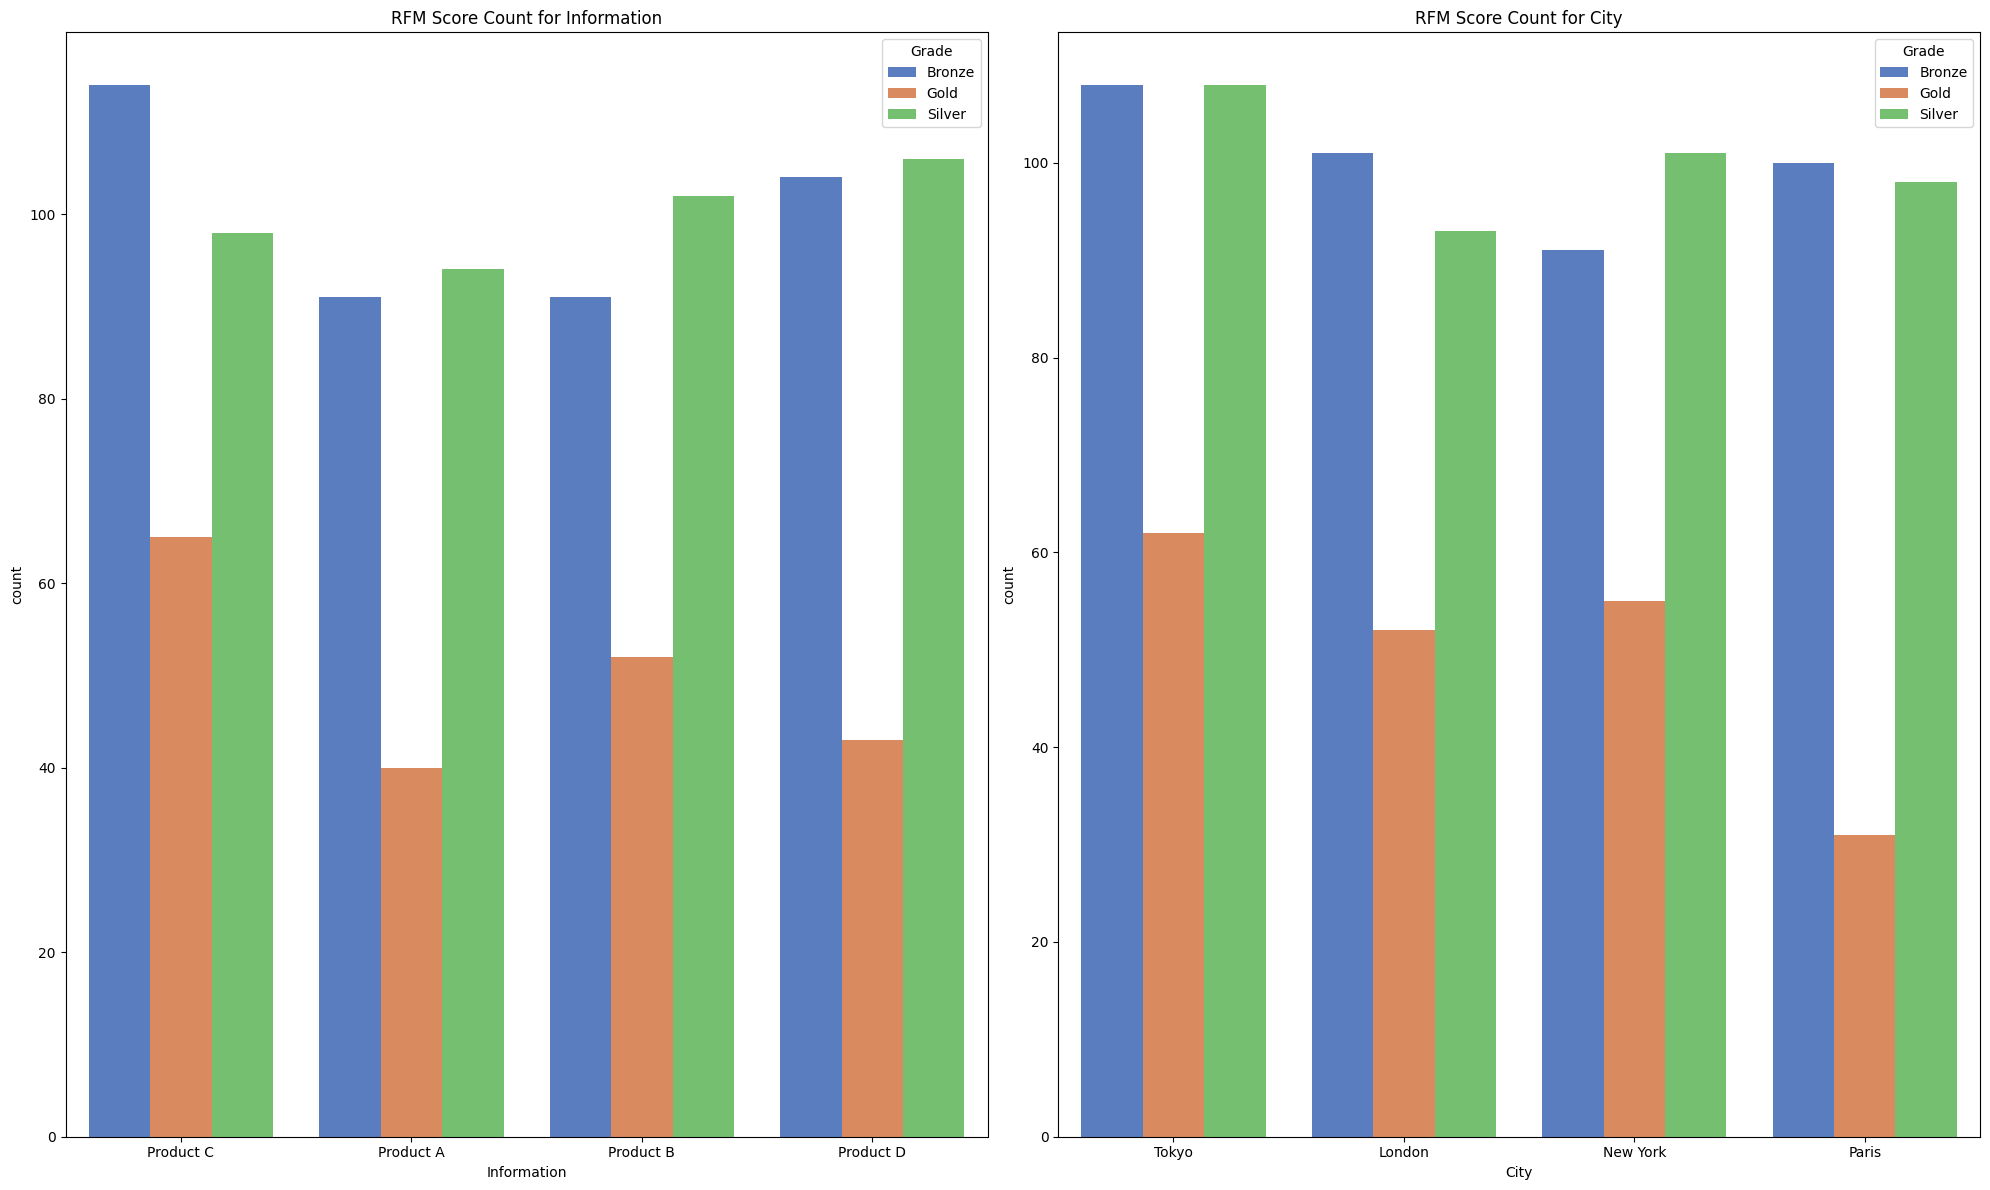

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(20, 12))

for i, col in enumerate(['Information', 'City']):
    sns.countplot(ax=axes[i], x=col, hue='Grade', data=co_rfm_df, palette='muted')
    axes[i].set_title(f'RFM Score Count for {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_10712\1951495570.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[i], x=col, data=co_rfm_df, palette='muted')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_10712\1951495570.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[i], x=col, data=co_rfm_df, palette='muted')


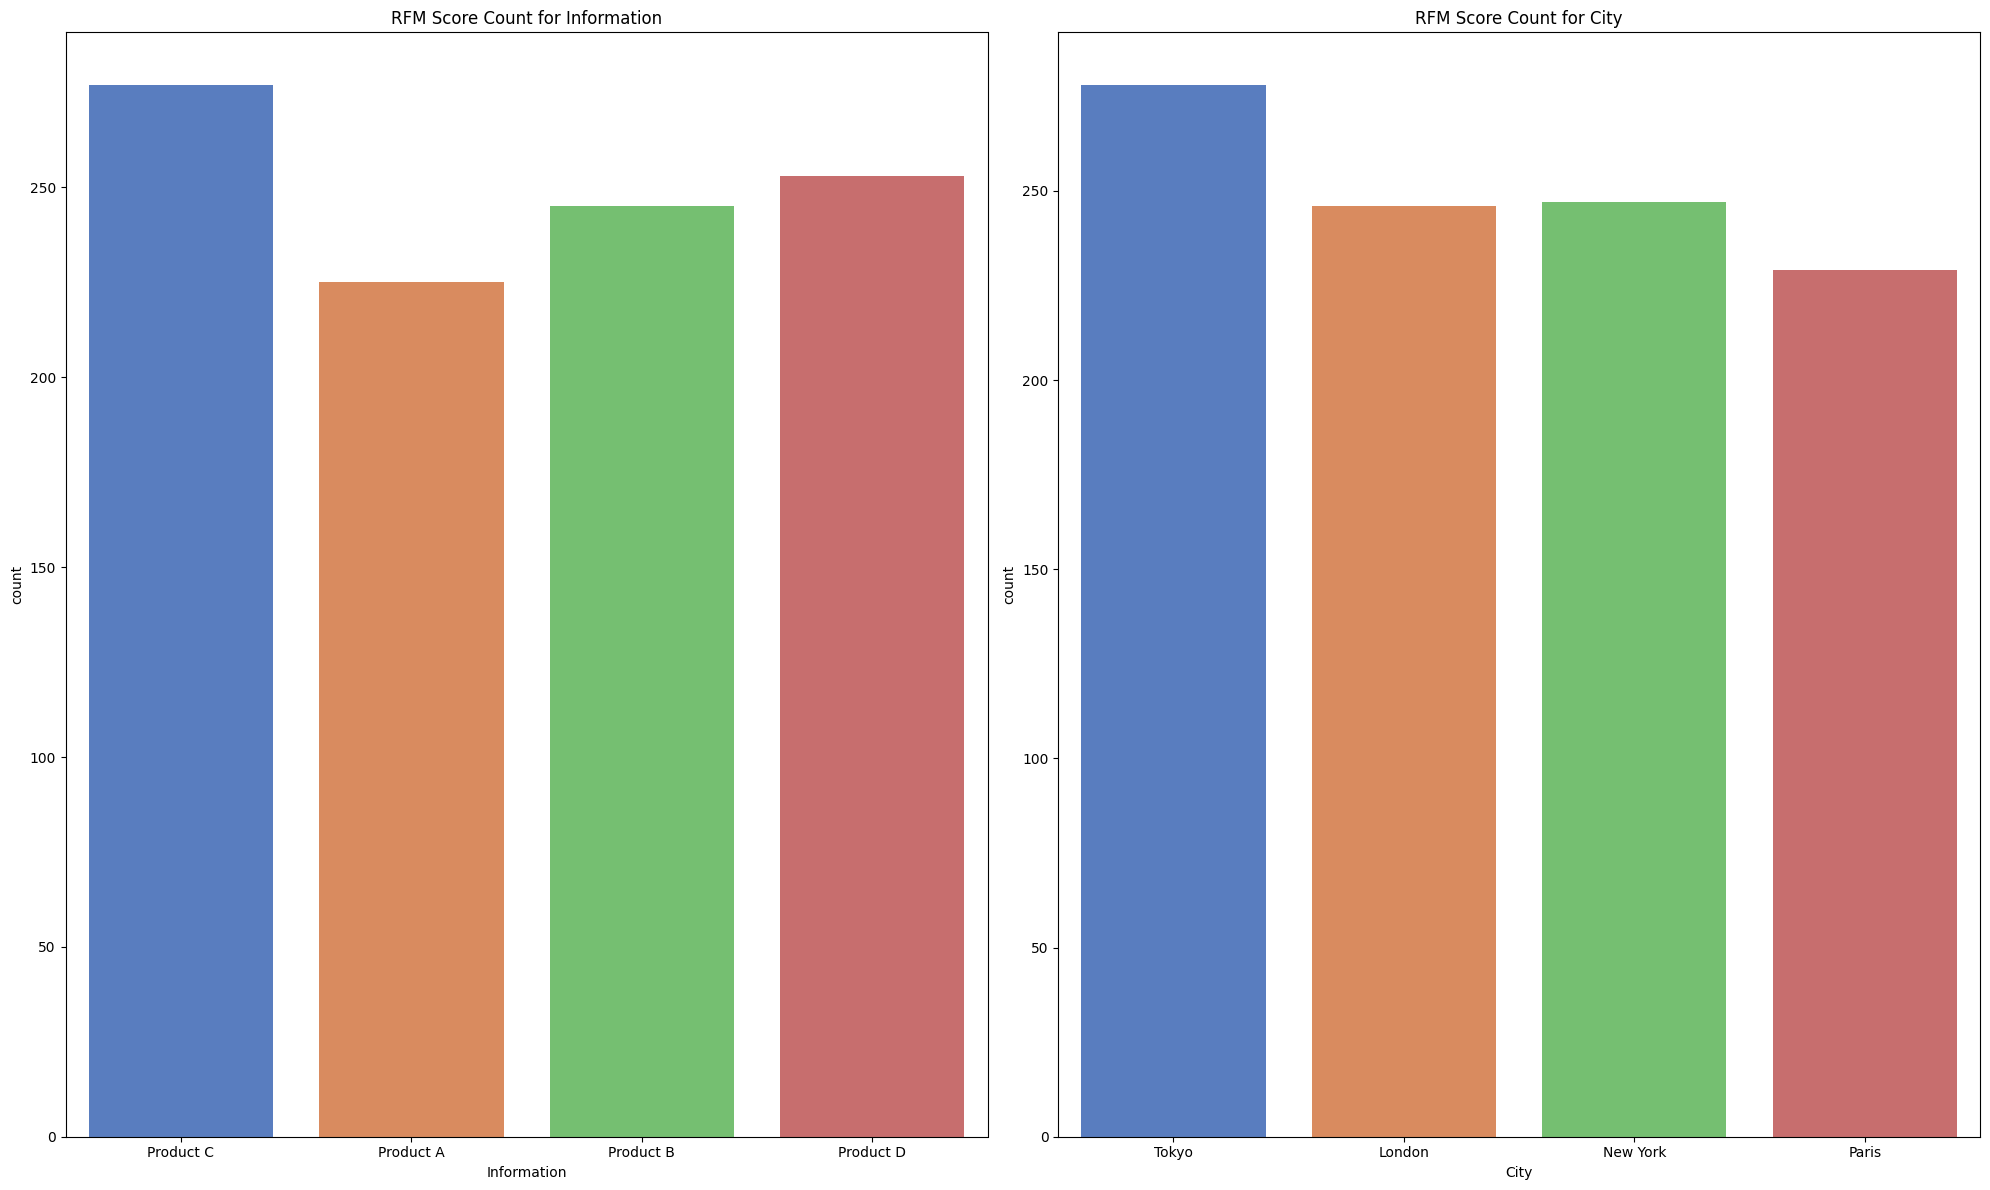

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(20, 12))

for i, col in enumerate(['Information', 'City']):
    sns.countplot(ax=axes[i], x=col, data=co_rfm_df, palette='muted')
    axes[i].set_title(f'RFM Score Count for {col}')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

#### 마케팅 전략

- 제품 마케팅  
제품 C와 D의 구매량이 높은 것을 고려하여 이 두 제품에 대한 마케팅 활동을 강화할 필요가 있습니다.
제품 C와 D에 대한 마케팅 활동을 통해 A와 B또한 같이 구매량을 높일 수 있는 전략입니다.

- 지역 타겟 마케팅  
도쿄와 뉴욕에 Gold등급이 많은 것으로 보아 해당 지역에서의 프로모션 및 이벤트를 통해 고객들의 만족도를 높일 필요가 있습니다.

- 등급별 마케팅  
고객들을 모두 고려하여 제품과 지역에 따른 다양한 프로모션 및 할인 이벤트를 제공해야 합니다. 이러한 마케팅 전략을 통해 제품 선호도와 지역 선호도를 고려한 타겟 마케팅을 실시하고, 각 등급의 고객들을 모두 고려한 다채로운 마케팅 활동을 펼쳐 고객들의 만족도를 높이고 매출을 증대시킬 수 있을 것으로 기대됩니다.